<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/Stats/Day_5_Pandas_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_excel('/content/drive/MyDrive/CDAC_DataBook.xlsx' ,sheet_name='ERPData')
df.head(5)


,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [6]:
x1 = np.random.randint(10,80,50)
x1

df['value'] = x1

In [7]:
df.head()

,MaterialID,Location,Quantity,value
0,TMI-43T,MWH-4,34,70
1,AXCP-78,MWH-1,67,75
2,LXCV-21,MWH-2,27,64
3,AXCP-78,MWH-5,65,60
4,AXCP-78,MWH-4,36,15


In [18]:
grp1 = df.groupby ('MaterialID')
print(grp1.groups         ,end='\n\n')
grp1.groups.keys()

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}



dict_keys(['AXCP-78', 'DDBN-89', 'GCVB-79', 'LXCV-21', 'SDRT-67', 'TMI-43T'])

In [19]:
df.iloc[[1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48]]
w1 = df.iloc[grp1.groups['AXCP-78']]
w1

,MaterialID,Location,Quantity,value
1,AXCP-78,MWH-1,67,75
3,AXCP-78,MWH-5,65,60
4,AXCP-78,MWH-4,36,15
24,AXCP-78,MWH-1,152,40
25,AXCP-78,MWH-1,109,72
37,AXCP-78,MWH-5,65,55
38,AXCP-78,MWH-5,70,18
39,AXCP-78,MWH-1,145,11
46,AXCP-78,MWH-2,85,58
47,AXCP-78,MWH-3,29,56


In [14]:
grp1.get_group('SDRT-67')

,MaterialID,Location,Quantity,value
10,SDRT-67,MWH-1,34,60
11,SDRT-67,MWH-4,58,21
16,SDRT-67,MWH-5,12,27
17,SDRT-67,MWH-5,102,53
41,SDRT-67,MWH-1,57,24
42,SDRT-67,MWH-2,31,24


<Axes: ylabel='Quantity'>

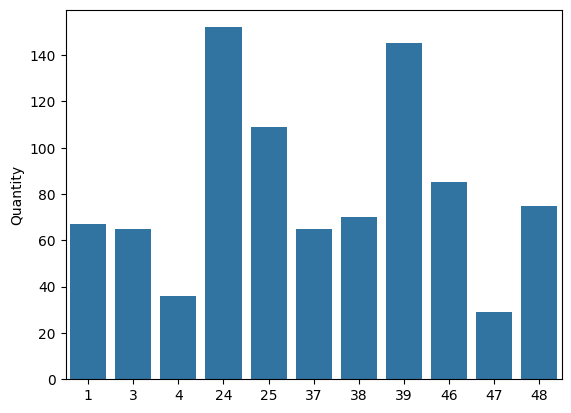

In [24]:
import seaborn as sns
sns.barplot(w1['Quantity'])

In [29]:
grp1.Quantity.mean() ### Here we can directly give the agg function
grp1.Quantity.agg(np.mean)  ## here we have to pass the agg ftcn into agg

/tmp/ipykernel_1088/1029878589.py:2: FutureWarning: The provided callable <function mean at 0x7b93de335940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grp1.Quantity.agg(np.mean)  ## here we have to pass the agg ftcn into agg


,Quantity
MaterialID,
AXCP-78,81.636364
DDBN-89,47.875000
GCVB-79,36.400000
LXCV-21,48.600000
SDRT-67,49.000000
TMI-43T,59.000000


In [36]:
grp1.Quantity.mean()
grp1.Quantity.sum()
grp1.Quantity.size()
grp1.Quantity.agg([np.mean,np.sum,np.size])

/tmp/ipykernel_1088/171127097.py:4: FutureWarning: The provided callable <function mean at 0x7b93de335940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grp1.Quantity.agg([np.mean,np.sum,np.size])
/tmp/ipykernel_1088/171127097.py:4: FutureWarning: The provided callable <function sum at 0x7b93de334860> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  grp1.Quantity.agg([np.mean,np.sum,np.size])


,mean,sum,size
MaterialID,,,
AXCP-78,81.636364,898,11
DDBN-89,47.875000,383,8
GCVB-79,36.400000,182,5
LXCV-21,48.600000,243,5
SDRT-67,49.000000,294,6
TMI-43T,59.000000,885,15


In [41]:
s1 = grp1.Quantity.size()  ## pandas.core.series.Series if there is a single column it is a series
type(s1)

s2 = grp1.Quantity.agg([np.mean,np.sum,np.size]) ## pandas.core.frame.DataFrame if there is a single column it is a DataFrame
type(s2)

/tmp/ipykernel_1088/2887716033.py:4: FutureWarning: The provided callable <function mean at 0x7b93de335940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  s2 = grp1.Quantity.agg([np.mean,np.sum,np.size]) ## pandas.core.frame.DataFrame if there is a single column it is a DataFrame
/tmp/ipykernel_1088/2887716033.py:4: FutureWarning: The provided callable <function sum at 0x7b93de334860> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  s2 = grp1.Quantity.agg([np.mean,np.sum,np.size]) ## pandas.core.frame.DataFrame if there is a single column it is a DataFrame


pandas.core.frame.DataFrame

In [45]:
s1 = grp1.Quantity.agg(np.size)  ### now it is series
s1

d1 = pd.DataFrame(s1)  ## pandas.core.frame.DataFrame
d1
type(d1)

pandas.core.frame.DataFrame

In [46]:
d1.loc['SDRT-67']

,SDRT-67
Quantity,6


In [54]:
np.where(d1.index == 'SDRT-67')
d1

d1.loc['SDRT-67']

,SDRT-67
Quantity,6


In [57]:
np.where(d1.index == 'SDRT-67')

(array([4]),)

In [60]:
d1.iloc[np.where(d1.index == 'SDRT-67')]

,Quantity
MaterialID,
SDRT-67,6


In [80]:
d2 = grp1.Quantity.agg([np.size,np.sum,np.size])
d2

d2.loc['SDRT-67' , 'sum']

# np.where(grp1.index == 'GCVB-79' )

d2.iloc[4,1]

d23 = np.where(d1.index == 'GCVB-79' )

d23 = d1.iloc[d23[0]]

type(d23)

d23

/tmp/ipykernel_1088/1378939958.py:1: FutureWarning: The provided callable <function sum at 0x7b93de334860> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  d2 = grp1.Quantity.agg([np.size,np.sum,np.size])


,Quantity
MaterialID,
GCVB-79,5


---
#






#
---

In [105]:
df = pd.read_excel('/content/drive/MyDrive/CDAC_DataBook.xlsx' , sheet_name = 'Health')
# df

# d = df.groupby(['Country','Disease'])
# d.groups

In [109]:
# | Part                             | Meaning                                                                |
# | -------------------------------- | ---------------------------------------------------------------------- |
# | `id_vars=['Country', 'Disease']` | These columns remain unchanged                                         |
# | `var_name='Year'`                | The melted column names become values under a new column called `Year` |
# | `value_name='Cases'`             | The data values go into a new column called `Cases`                    |


# the columns does not want to          the column names which i want to       the values of that columns that become
# change came in id_vars                 as value came in var_name             values that came in the value_name
#                   \--------------                        |                     ---------------/
#                                  V                       V                     V
df1 = df.melt(id_vars = ['Country' , 'Disease'] , var_name = 'Year' , value_name = 'Cases')
df1


,Country,Disease,Year,Cases
0,India,Cancer,2019,12
1,UK,Cancer,2019,95
2,US,Cancer,2019,98
3,Japan,Cancer,2019,89
4,India,Covid,2019,38
5,UK,Covid,2019,69
6,US,Covid,2019,87
7,Japan,Covid,2019,14
8,India,Heart Attack,2019,84
9,UK,Heart Attack,2019,44


In [107]:
print(df.shape)
df1.shape

(12, 5)


(36, 4)

In [141]:
df2 = df1.pivot_table(values = 'Cases' , index = ['Country' ,'Year'] , columns = 'Disease')
df2

Disease       Cancer  Covid  Heart Attack
Country Year                             
India   2019    12.0   38.0          84.0
        2020    94.0   19.0          10.0
        2021    35.0   62.0          98.0
Japan   2019    89.0   14.0          11.0
        2020    52.0   12.0          43.0
        2021    14.0   90.0          75.0
UK      2019    95.0   69.0          44.0
        2020    19.0   73.0          17.0
        2021    84.0   35.0          24.0
US      2019    98.0   87.0          34.0
        2020    19.0   97.0          40.0
        2021    53.0   35.0          54.0

In [147]:
df2.loc[ [['India',2019] , ['US',2019]] ]
df2.loc[ [['India', 2019]] ]

,Disease,Cancer,Covid,Heart Attack
Country,Year,,,
India,2019,12.0,38.0,84.0


In [144]:
df2.index

MultiIndex([('India', 2019),
            ('India', 2020),
            ('India', 2021),
            ('Japan', 2019),
            ('Japan', 2020),
            ('Japan', 2021),
            (   'UK', 2019),
            (   'UK', 2020),
            (   'UK', 2021),
            (   'US', 2019),
            (   'US', 2020),
            (   'US', 2021)],
           names=['Country', 'Year'])

In [ ]:
df211 = df1.pivot_table(values = 'Cases' , index = ['Year' , 'Country' ] , columns = 'Disease')
df211

In [113]:
df2.shape

(12, 3)

In [158]:
# .reset_index() it will remove labels from the DataFrame of the labels column
#  it will convert the labels into columns

df2 = df1.pivot_table(values = 'Cases' , index = ['Country' ,'Year'] , columns = 'Disease').reset_index()
print(df2)

print()

we = np.where(df2.Country == "India")
df2.iloc[we [0]]

Disease Country  Year  Cancer  Covid  Heart Attack
0         India  2019    12.0   38.0          84.0
1         India  2020    94.0   19.0          10.0
2         India  2021    35.0   62.0          98.0
3         Japan  2019    89.0   14.0          11.0
4         Japan  2020    52.0   12.0          43.0
5         Japan  2021    14.0   90.0          75.0
6            UK  2019    95.0   69.0          44.0
7            UK  2020    19.0   73.0          17.0
8            UK  2021    84.0   35.0          24.0
9            US  2019    98.0   87.0          34.0
10           US  2020    19.0   97.0          40.0
11           US  2021    53.0   35.0          54.0



Disease,Country,Year,Cancer,Covid,Heart Attack
0,India,2019,12.0,38.0,84.0
1,India,2020,94.0,19.0,10.0
2,India,2021,35.0,62.0,98.0


In [156]:
# rename_axis(columns = None) it will remove label name of the index column

df2 = df1.pivot_table(values = 'Cases' , index = ['Country' ,'Year'] , columns = 'Disease').reset_index().rename_axis(columns = None)
print(df2)

   Country  Year  Cancer  Covid  Heart Attack
0    India  2019    12.0   38.0          84.0
1    India  2020    94.0   19.0          10.0
2    India  2021    35.0   62.0          98.0
3    Japan  2019    89.0   14.0          11.0
4    Japan  2020    52.0   12.0          43.0
5    Japan  2021    14.0   90.0          75.0
6       UK  2019    95.0   69.0          44.0
7       UK  2020    19.0   73.0          17.0
8       UK  2021    84.0   35.0          24.0
9       US  2019    98.0   87.0          34.0
10      US  2020    19.0   97.0          40.0
11      US  2021    53.0   35.0          54.0


In [160]:
df = pd.read_excel('/content/drive/MyDrive/CDAC_DataBook.xlsx' , sheet_name = 'ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [176]:
df1 = df.pivot_table(values = 'Quantity' ,index =['MaterialID'] , columns = 'Location') #<---------------- there is a default agg function is mean
df1 = df.pivot_table(values = 'Quantity' ,index =['MaterialID'] , columns = 'Location' , aggfunc = 'mean') # <=-------------you can change the agg function to sum ,size

df1 = df.pivot_table(values = 'Quantity' ,index =['MaterialID'] , columns = 'Location' , aggfunc = 'size')

print(df1.shape)
print(df1.reset_index())

(6, 5)
Location MaterialID  MWH-1  MWH-2  MWH-3  MWH-4  MWH-5
0           AXCP-78    5.0    1.0    1.0    1.0    3.0
1           DDBN-89    3.0    1.0    1.0    2.0    1.0
2           GCVB-79    NaN    4.0    NaN    NaN    1.0
3           LXCV-21    NaN    1.0    1.0    NaN    3.0
4           SDRT-67    2.0    1.0    NaN    1.0    2.0
5           TMI-43T    1.0    1.0    1.0   11.0    1.0
